Step 1: Load and Prepare Data

In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv("ev_energy_with_weather.csv")

# Convert 'date' to datetime and sort
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').set_index('date')


Ensures dates are sorted and usable for time-based operations.
Using date as the index makes rolling and shifting easier.

 Step 2: Feature Engineering

In [2]:
# Time-based features
df['is_weekend'] = (df.index.dayofweek >= 5).astype(int)
df['day_of_week'] = df.index.dayofweek
df['month'] = df.index.month
df['is_winter'] = df['month'].isin([12, 1, 2]).astype(int)

# Weather features
df['temp_range'] = df['t_max'] - df['t_min']

# Energy history features
df['lag_1_energy'] = df['energy'].shift(1)
df['rolling_energy_7d'] = df['energy'].rolling(window=7).mean().shift(1)
df['rolling_energy_14d'] = df['energy'].rolling(window=14).mean().shift(1)

# Target: energy at t+1 (next day)
df['target_energy_t_plus_1'] = df['energy'].shift(-1)

# Remove rows with missing values
df = df.dropna()


Creates features from time, temperature, and past energy usage.
shift(1) → use yesterday's value.
shift(-1) → target is tomorrow's energy.
dropna() removes rows with incomplete data due to rolling or shifting.

 Step 3: Select Features & Target

In [3]:
# Define features and target
feature_cols = [
    't_max', 't_min', 'precip', 'snow', 'snow_depth',
    'is_weekend', 'day_of_week', 'month', 'is_winter',
    'temp_range', 'lag_1_energy', 'rolling_energy_7d', 'rolling_energy_14d'
]
target_col = 'target_energy_t_plus_1'

X = df[feature_cols]
y = df[target_col]


Step 4: Train/Test Split (time-aware)

In [4]:
from sklearn.model_selection import train_test_split

# Split without shuffling (time series!)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)


Don’t shuffle time series — future must not "see" the past.
test_size=0.2 = use last 20% of data as test set.

🧼 Step 5: Feature Scaling

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Standardizes features to zero mean and unit variance — important for many ML models.

Step 6: Train Random Forest Model



In [6]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)


RandomForestRegressor(random_state=42)

Step 7: Evaluate the Model



In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = rf.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"📏 MAE:  {mae:.2f}")
print(f"📐 RMSE: {rmse:.2f}")
print(f"📉 R²:   {r2:.4f}")


📏 MAE:  207.87
📐 RMSE: 322.91
📉 R²:   -0.4793



-MAE (Mean Absolute Error)	207.87 kWh	On average,  prediction is off by ~208 kWh

-RMSE (Root Mean Squared Error)	322.91 kWh	Larger errors are penalized more — high value shows volatility

-R² (R-squared)	−0.4793	A negative R² means the model performs worse than just predicting the mean of the target

Step 8: Feature Importance Plot



C:\Users\KHALIL\AppData\Local\Temp\ipykernel_2280\3394468214.py:14: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\KHALIL\anaconda3\envs\evforecast\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


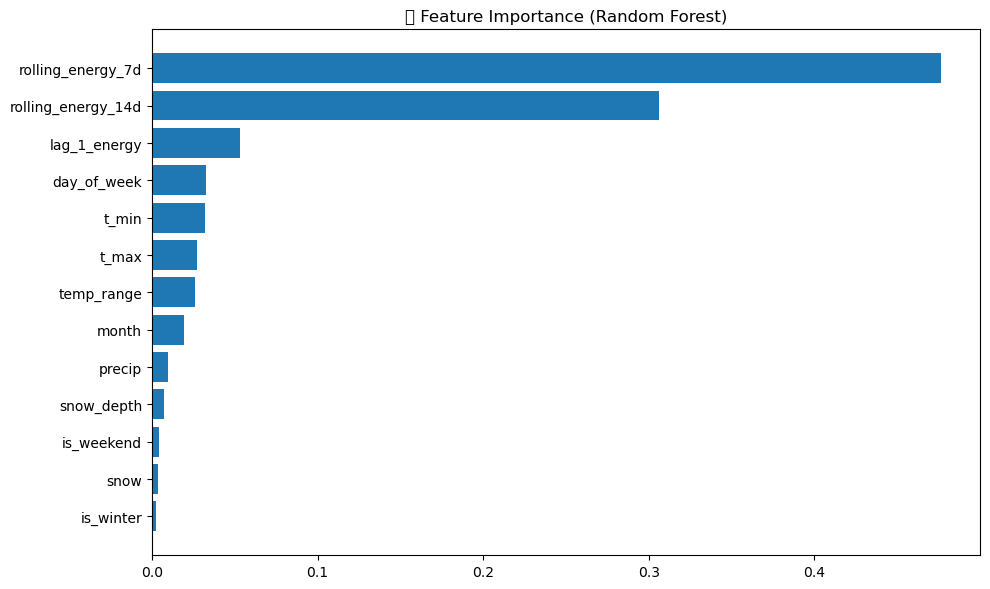

In [9]:
import matplotlib.pyplot as plt

# Create dataframe for plotting
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.title("🔍 Feature Importance (Random Forest)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


1️⃣	rolling_energy_7d	⭐ Very High	Short-term weekly average is most predictive
2️⃣	rolling_energy_14d	⭐ High	Mid-term energy trend also useful
3️⃣	lag_1_energy	Moderate	Yesterday’s value still helps
4️⃣–7️⃣	day_of_week, t_min, t_max, temp_range	Low-to-mid	Weather and weekday effects
8️⃣–13️⃣	month, precip, snow, etc.	Very low	Minimal contribution

tuning 24 combinations of hyperparameters across 3 folds.

In [10]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Define the hyperparameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Base model
rf = RandomForestRegressor(random_state=42)

# Grid Search with 3-fold cross-validation
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

# Fit the grid search
grid_search.fit(X_train_scaled, y_train)

# Best model
best_rf = grid_search.best_estimator_

# Predict on test data
y_pred_best = best_rf.predict(X_test_scaled)

# Evaluate
mae_best = mean_absolute_error(y_test, y_pred_best)
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
r2_best = r2_score(y_test, y_pred_best)

# Show results
print("✅ Best Parameters:", grid_search.best_params_)
print(f"📏 MAE:  {mae_best:.2f}")
print(f"📐 RMSE: {rmse_best:.2f}")
print(f"📉 R²:   {r2_best:.4f}")


Fitting 3 folds for each of 24 candidates, totalling 72 fits
✅ Best Parameters: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
📏 MAE:  201.99
📐 RMSE: 316.52
📉 R²:   -0.4214
